In [47]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("Sample-Superstore.csv",encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [48]:
df.shape

(9994, 21)

In [49]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [50]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [51]:
df[['Sales','Profit','Quantity','Discount']].describe()

,Sales,Profit,Quantity,Discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574,0.156203
std,623.245101,234.260108,2.225110,0.206452
min,0.444000,-6599.978000,1.000000,0.000000
25%,17.280000,1.728750,2.000000,0.000000
50%,54.490000,8.666500,3.000000,0.200000
75%,209.940000,29.364000,5.000000,0.200000
max,22638.480000,8399.976000,14.000000,0.800000


In [52]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

df['Year']=df['Order Date'].dt.year
df['Month']=df['Order Date'].dt.month
df['Month_Year']=df['Order Date'].dt.to_period('M')

df['Order Date'].dtype
df['Year'].unique()

array([2016, 2015, 2014, 2017], dtype=int32)

In [53]:
yearly=df.groupby('Year')[['Sales', 'Profit']].sum().round(2)
yearly

,Sales,Profit
Year,,
2014,484247.50,49543.97
2015,470532.51,61618.60
2016,609205.60,81795.17
2017,733215.26,93439.27


In [54]:
category_sales=df.groupby('Category')['Sales'].sum().round(2).sort_values(ascending=False)
category_sales

Category
Technology         836154.03
Furniture          741999.80
Office Supplies    719047.03
Name: Sales, dtype: float64

In [55]:
sub_cat_sales=df.groupby('Sub-Category')['Sales'].sum().round(2).sort_values(ascending=False)
sub_cat_sales

Sub-Category
Phones         330007.05
Chairs         328449.10
Storage        223843.61
Tables         206965.53
Binders        203412.73
Machines       189238.63
Accessories    167380.32
Copiers        149528.03
Bookcases      114880.00
Appliances     107532.16
Furnishings     91705.16
Paper           78479.21
Supplies        46673.54
Art             27118.79
Envelopes       16476.40
Labels          12486.31
Fasteners        3024.28
Name: Sales, dtype: float64

In [56]:
region_sales=df.groupby('Region')['Sales'].sum().round(2).sort_values(ascending=False)
region_sales

Region
West       725457.82
East       678781.24
Central    501239.89
South      391721.90
Name: Sales, dtype: float64

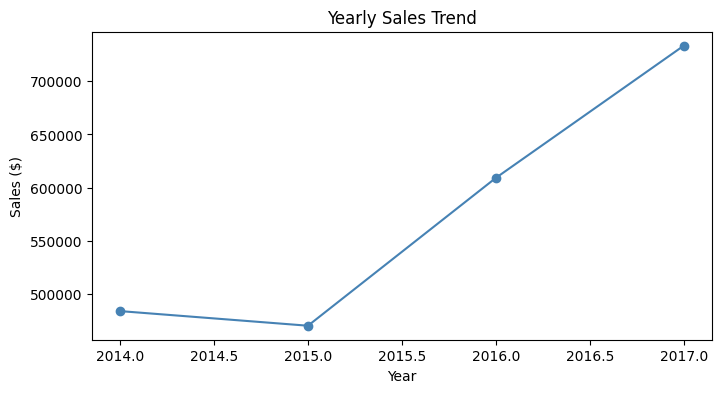

In [64]:
yearly['Sales'].plot(kind='line',marker='o',color='steelblue',figsize=(8,4),title='Yearly Sales Trend')
plt.ylabel('Sales ($)')
plt.xlabel('Year')
plt.savefig('images/yearly_sales.png',dpi=150,bbox_inches='tight')

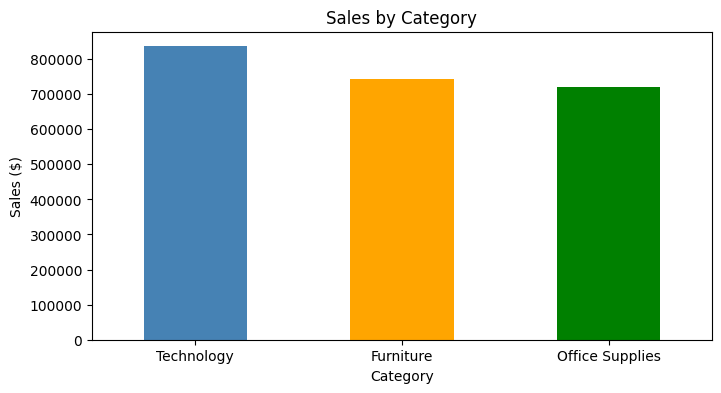

In [65]:
category_sales.plot(kind='bar',color=['steelblue','orange','green'],figsize=(8,4),title='Sales by Category')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.savefig('images/category_sales.png',dpi=150,bbox_inches='tight')

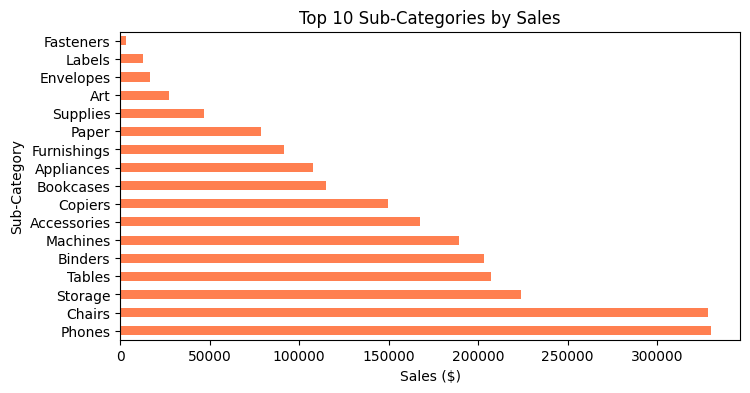

In [66]:
sub_cat_sales.plot(kind='barh',color='coral',figsize=(8,4),title='Top 10 Sub-Categories by Sales')
plt.xlabel('Sales ($)')
plt.savefig('images/subcat_sales.png',dpi=150,bbox_inches='tight')

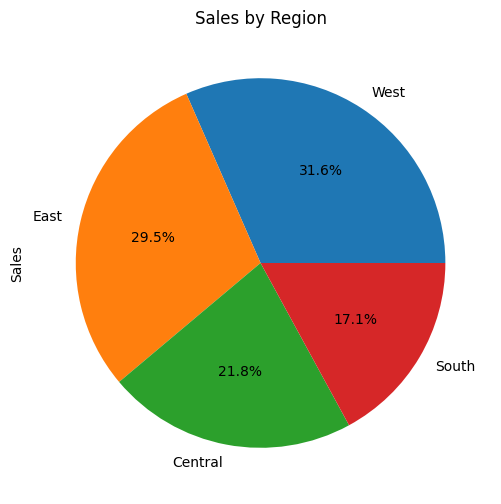

In [67]:
region_sales.plot(kind='pie',autopct='%1.1f%%',figsize=(6,6),title='Sales by Region')
plt.savefig('images/region_sales.png',dpi=150,bbox_inches='tight')

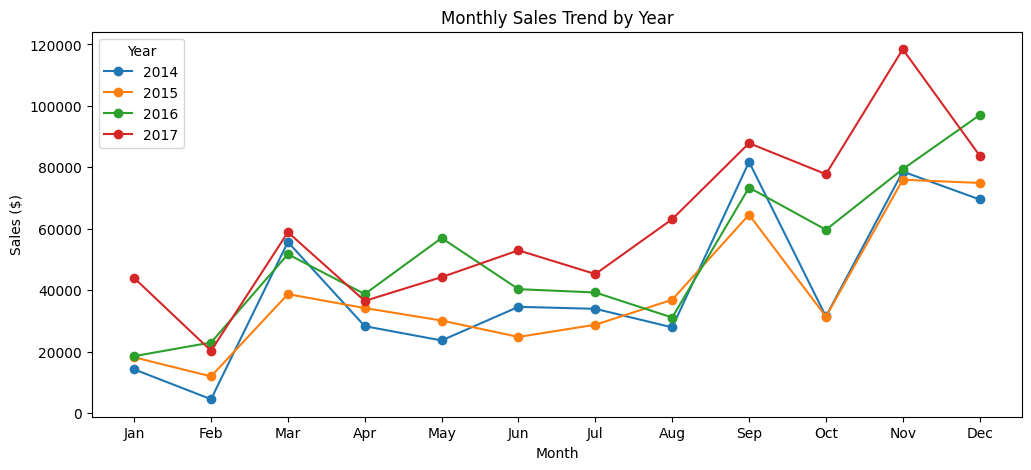

In [68]:
monthly=df.groupby(['Year','Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
for year in monthly['Year'].unique():
    data=monthly[monthly['Year']==year]
    plt.plot(data['Month'],data['Sales'],marker='o',label=str(year))

plt.title('Monthly Sales Trend by Year')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(range(1,13),['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Year')
plt.savefig('images/monthly_trend.png', dpi=150, bbox_inches='tight')

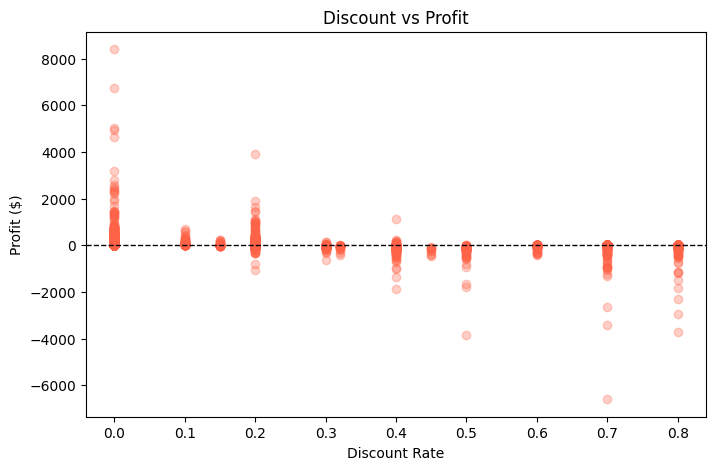

In [69]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'],df['Profit'],alpha=0.3,color='tomato')
plt.axhline(y=0,color='black',linestyle='--',linewidth=1)
plt.title('Discount vs Profit')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.savefig('images/discount_profit.png',dpi=150,bbox_inches='tight')

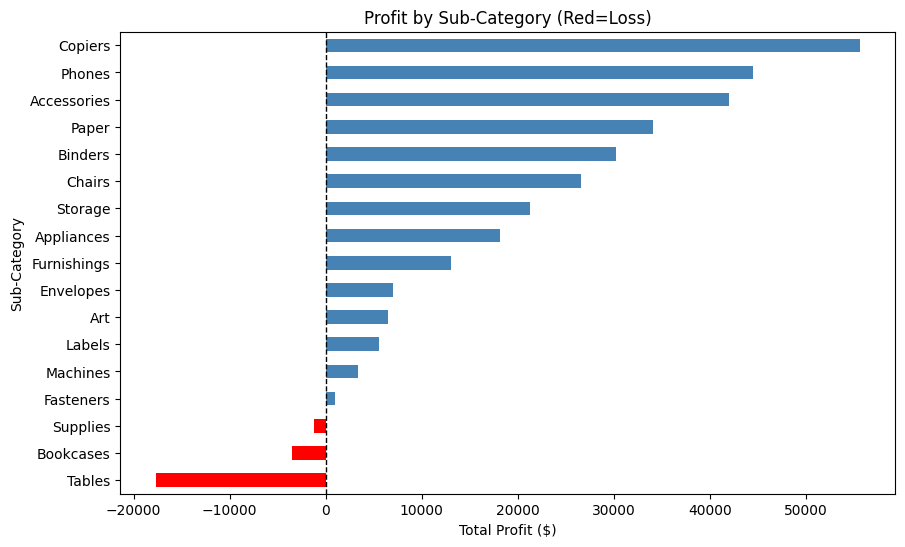

In [70]:
subcat_profit=df.groupby('Sub-Category')['Profit'].sum().round(2).sort_values()
colors=['red' if x<0 else 'steelblue' for x in subcat_profit]
plt.figure(figsize=(10,6))
subcat_profit.plot(kind='barh',color=colors)
plt.axvline(x=0,color='black',linestyle='--',linewidth=1)
plt.title('Profit by Sub-Category (Red=Loss)')
plt.xlabel('Total Profit ($)')
plt.savefig('images/subcat_profit.png',dpi=150,bbox_inches='tight')

## 📊 Key Insights & Analysis Summary

### 📈 Yearly Sales Trend
- Sales grew steadily from **$484K (2014)** to **$733K (2017)** — a **51% increase over 4 years**
- Profit also improved year-on-year, with 2017 recording the highest at **$93K**

### 🛍️ Sales by Category
- **Technology** leads with **$836K** in total sales
- **Furniture** and **Office Supplies** follow closely at $742K and $719K respectively

### 📦 Top Sub-Categories
- **Phones ($330K)** and **Chairs ($328K)** are the top-selling sub-categories
- These two alone account for nearly **30% of total sales**

### 🌍 Regional Performance
- The **West region** dominates with **$725K (30.6%)** of total sales
- The **South region** is the weakest at **$391K** — potential growth opportunity

### 📅 Monthly Seasonality
- Sales consistently **spike in September, November and December** across all years
- This pattern suggests strong **holiday and back-to-school demand**
- **November 2017** recorded the single highest monthly sales at **~$118K**

### 💸 Discount vs Profit
- Orders with **0% discount** are almost always profitable
- Orders with **discounts above 40%** frequently result in **losses**
- Heavy discounting is directly correlated with **negative profit margins**

### 🔴 Profit by Sub-Category
- **Copiers, Phones and Accessories** are the most profitable sub-categories
- **Tables (-$17K) and Bookcases (-$3K)** are running at a loss
- Loss-making sub-categories are likely victims of **excessive discounting**